In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import ArrayLike, NDArray

w = np.array([1, 1])
d = 1

 ## Note
 **法線ベクトル$w$、切片$d$の平面の式:**
 $$ w \cdot x + d = 0$$
 ここで、$w \cdot x = -d$と移項して、両辺を$|w|$で割ると
 $$\frac{w \cdot x}{|w|} = \frac{-d}{|w|}$$
 となり、原点を通る直線から、$-d/|w|$だけ離れた並行する直線となっている

g([-1, 0, 1], w, d) = array([ 0., -1., -2.])


<ipython-input-2-6de4fe6c8e3d>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


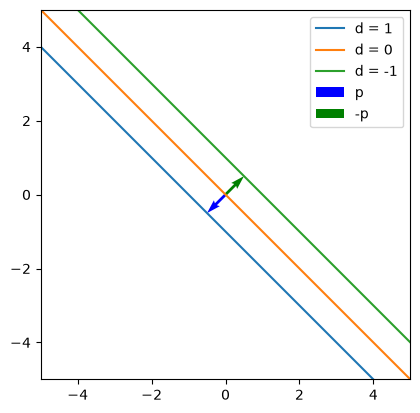

In [ ]:
def g(x0: NDArray | ArrayLike, w: NDArray, d: float) -> NDArray:
    # x0を受け取りx1を返す閉形式の直線の関数
    x0 = np.asarray(x0)
    return -(w[0] * x0 + d) / w[1]


print(f"{g([-1, 0, 1], w, d) = }")

x = np.linspace(-5, 5, 2)
dist = -d / np.linalg.norm(w)
e = w / np.linalg.norm(w)
p = e * dist

params = {
    "angles": "xy",
    "scale_units": "xy",
    "scale": 1,
}

fig, ax = plt.subplots()
fig.gca().set_aspect("equal")
ax.plot(x, g(x, w, d), label=f"d = {d}")
ax.plot(x, g(x, w, 0), label="d = 0")
ax.plot(x, g(x, w, -d), label=f"d = {-d}")
ax.quiver(0, 0, *p, label="p", color=["b"], **params)
ax.quiver(0, 0, *-p, label="-p", color=["g"], **params)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.legend()
fig.show()

 ## Note
 **直線と点の距離:**
 原点を通る直線と点の符号付きの距離は$(w \cdot p) / |w|$であり、
 そこから$-d/|w|$ずれているので、
 $$\frac{w \cdot p}{|w|} - \frac{-d}{|w|}$$
 整理して、絶対値をとると
 $$距離 = \frac{|w \cdot p + d|}{|w|}$$
 で計算される

In [ ]:
p = np.array([3, 0])
dist = np.abs(w @ p + d) / np.linalg.norm(w)

e = w / np.linalg.norm(w)
l = e * dist

<ipython-input-4-1de9ec34143d>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


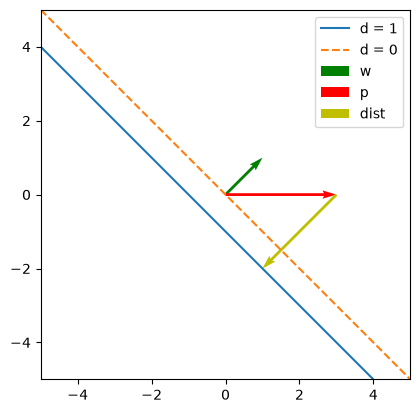

In [ ]:
x = np.linspace(-5, 5, 2)
fig, ax = plt.subplots()
fig.gca().set_aspect("equal")
ax.plot(x, g(x, w, d), label=f"d = {d}")
ax.plot(x, g(x, w, 0), linestyle="--", label="d = 0")
ax.quiver(0, 0, *w, label="w", color=["g"], **params)
ax.quiver(0, 0, *p, label="p", color=["r"], **params)
ax.quiver(p[0], p[1], *-l, label="dist", color=["y"], **params)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.legend()
fig.show()

 **補足:**
 - wとpは原点からのベクトルなので、始点は直線上にない
 - 距離は点 $p$ から直線までの距離になっている